# Portfolio Construction

Inverse-variance, minimum-volatility and maximum-Sharpe allocations (AFML Ch. 16 baselines) on the
**synthetic** futures panel (`make_synthetic_futures_dataset`, seed 9).

In [1]:
import nbfigures
import openquant

ds = openquant.research.make_synthetic_futures_dataset(n_bars=150, seed=9)
ivp = openquant.portfolio.allocate_inverse_variance(ds.asset_prices)
mv = openquant.portfolio.allocate_min_vol(ds.asset_prices)
msr = openquant.portfolio.allocate_max_sharpe(ds.asset_prices, risk_free_rate=0.0)
ivp, mv, msr

(([0.2480219068496025,
   0.24051799544811348,
   0.26745891296246305,
   0.2440011847398209],
  0.0008885602723890962,
  0.018650300578590857,
  0.0),
 ([0.138978856277775,
   0.2730662936770125,
   0.34045623177908857,
   0.24749861826582614],
  0.000868173890229825,
  0.01961896911117454,
  0.0),
 ([0.0875886796545883,
   0.36024053945321716,
   0.42728969456154303,
   0.12488108633065151],
  0.0009149552599245612,
  0.0217902623263199,
  23.815658842287572))

In [2]:
w_df = openquant.adapters.to_polars_weights_frame(ds.asset_names, msr[0])
assert abs(sum(msr[0]) - 1.0) < 1e-6
w_df

asset,weight
str,f64
"""CL""",0.087589
"""NG""",0.360241
"""RB""",0.42729
"""GC""",0.124881


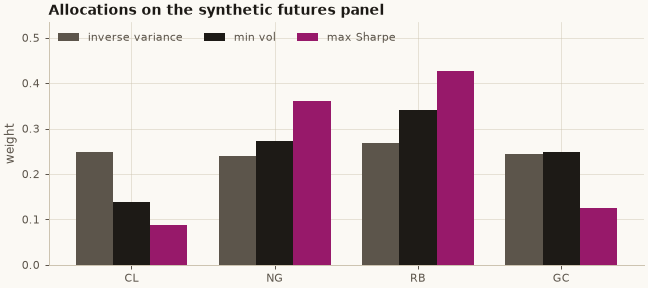

In [3]:
allocations = {"inverse variance": ivp[0], "min vol": mv[0], "max Sharpe": msr[0]}


def draw(fig, c):
    ax = fig.subplots()
    colors = [c["muted"], c["text"], c["accent"]]
    width = 0.26
    for k, (label, weights) in enumerate(allocations.items()):
        xs = [i + (k - 1) * width for i in range(len(ds.asset_names))]
        ax.bar(xs, weights, width=width, color=colors[k], label=label)
    ax.axhline(0.0, color=c["muted"], linewidth=0.8)
    ax.set_xticks(range(len(ds.asset_names)), ds.asset_names)
    ax.set_ylabel("weight")
    ax.set_title("Allocations on the synthetic futures panel")
    ax.set_ylim(0.0, 1.25 * max(max(w) for w in allocations.values()))
    ax.legend(ncols=3, loc="upper left")


nbfigures.figure(
    "nb04-allocations",
    draw,
    alt="Grouped bars comparing inverse-variance, minimum-volatility and maximum-Sharpe weights per asset.",
)